In [152]:
import numpy as np
import bayesflow as bf
import keras
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pickle
from benchmark.examples.gaussian.approximators.simulator import Simulator    
from benchmark.examples.gaussian.approximators.approximators import BayesFLowNPE 
from benchmark.examples.gaussian.datasets.datasets import GetDatasets 
from benchmark.examples.gaussian.datasets.stan_dataset import  StanDataset
from benchmark.examples.gaussian.datasets.calculation import Calculation
from benchmark.examples.gaussian.datasets.analysis import Analysis

In [153]:
RNG=np.random.default_rng(2025)
mu_prior_mean=0
mu_prior_std=1
num_dims=5
num_obs=100
likelihood_std=1

In [3]:
simulator_bayes=Simulator(mu_prior_mean=mu_prior_mean, mu_prior_std=mu_prior_std, 
                          num_dims=num_dims, num_obs=num_obs,
                          likelihood_std=likelihood_std,rng=RNG)
simulator=simulator_bayes.get_bayes_simulator()
bayesflownpe=BayesFLowNPE(simulator=simulator)
bayesflownpe._build_workflow()
history=bayesflownpe.train(epochs=100,batch_size=64,num_batches_per_epoch=200)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - loss: 4.6314
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - loss: 2.8715
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: 1.8257
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 1.1348
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - loss: 0.5982
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 0.0639
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: -0.3531
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - loss: -0.7700
Epoch 9/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: -1.1713
Epoch 10/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - loss: -1.5264
Epoch 11/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - loss: -1.7789
Epoch 12/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: -1.9512
Epoch 13/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - loss: -2.1851
Epoch 14/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: -2.2213
Epoch 15/

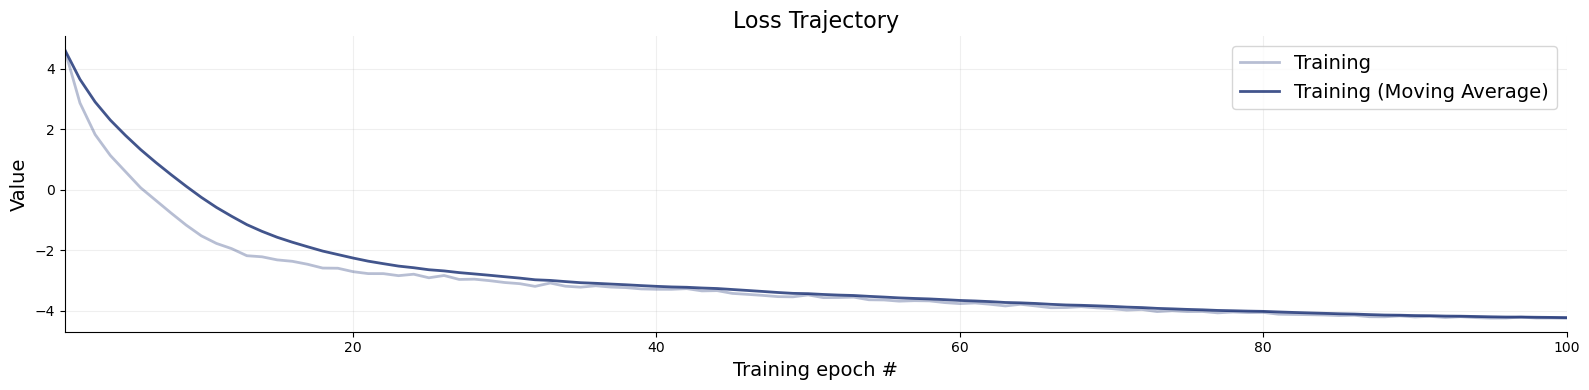

In [4]:
f=bf.diagnostics.plots.loss(history)

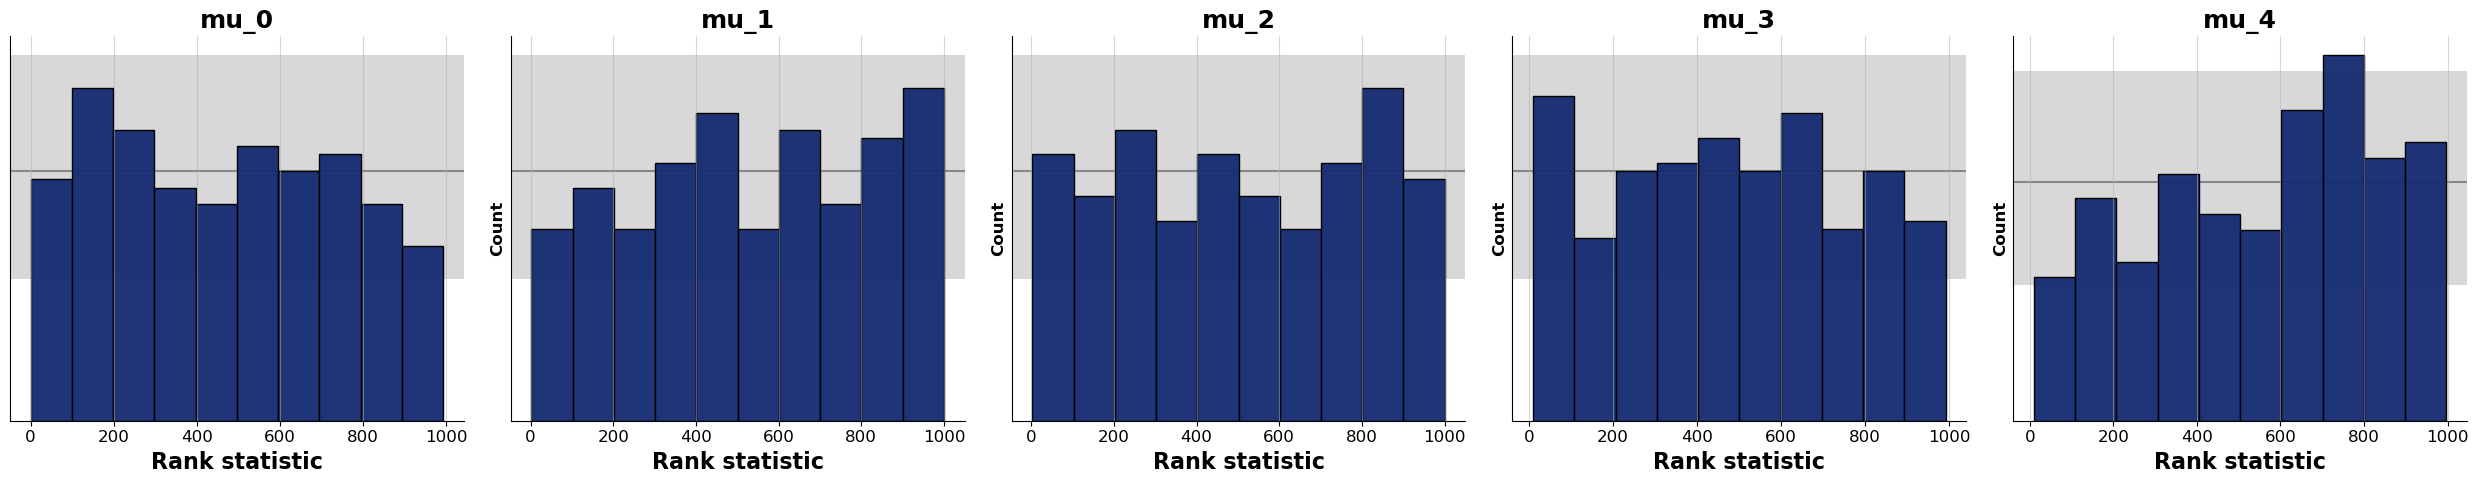

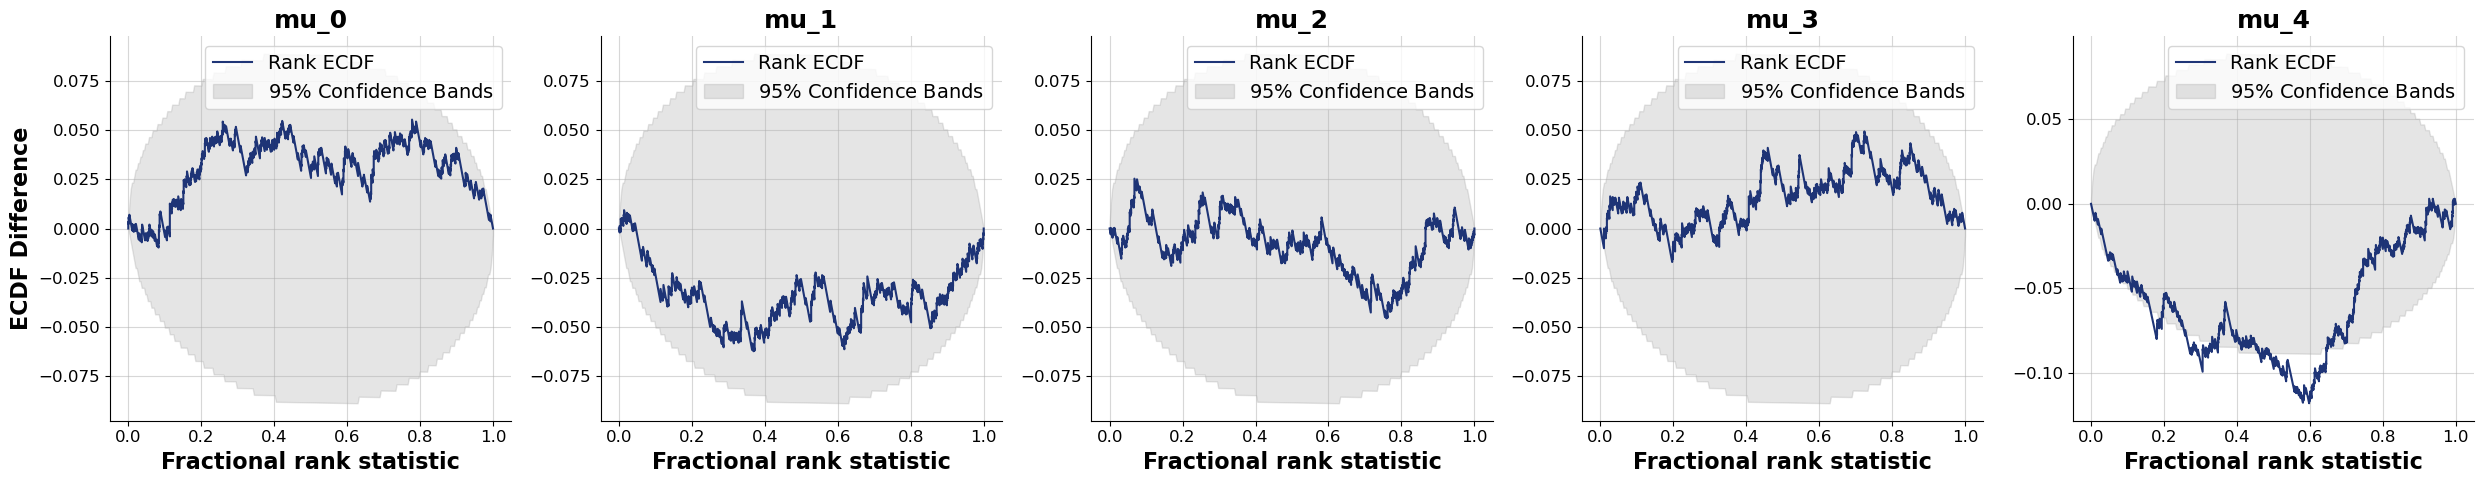

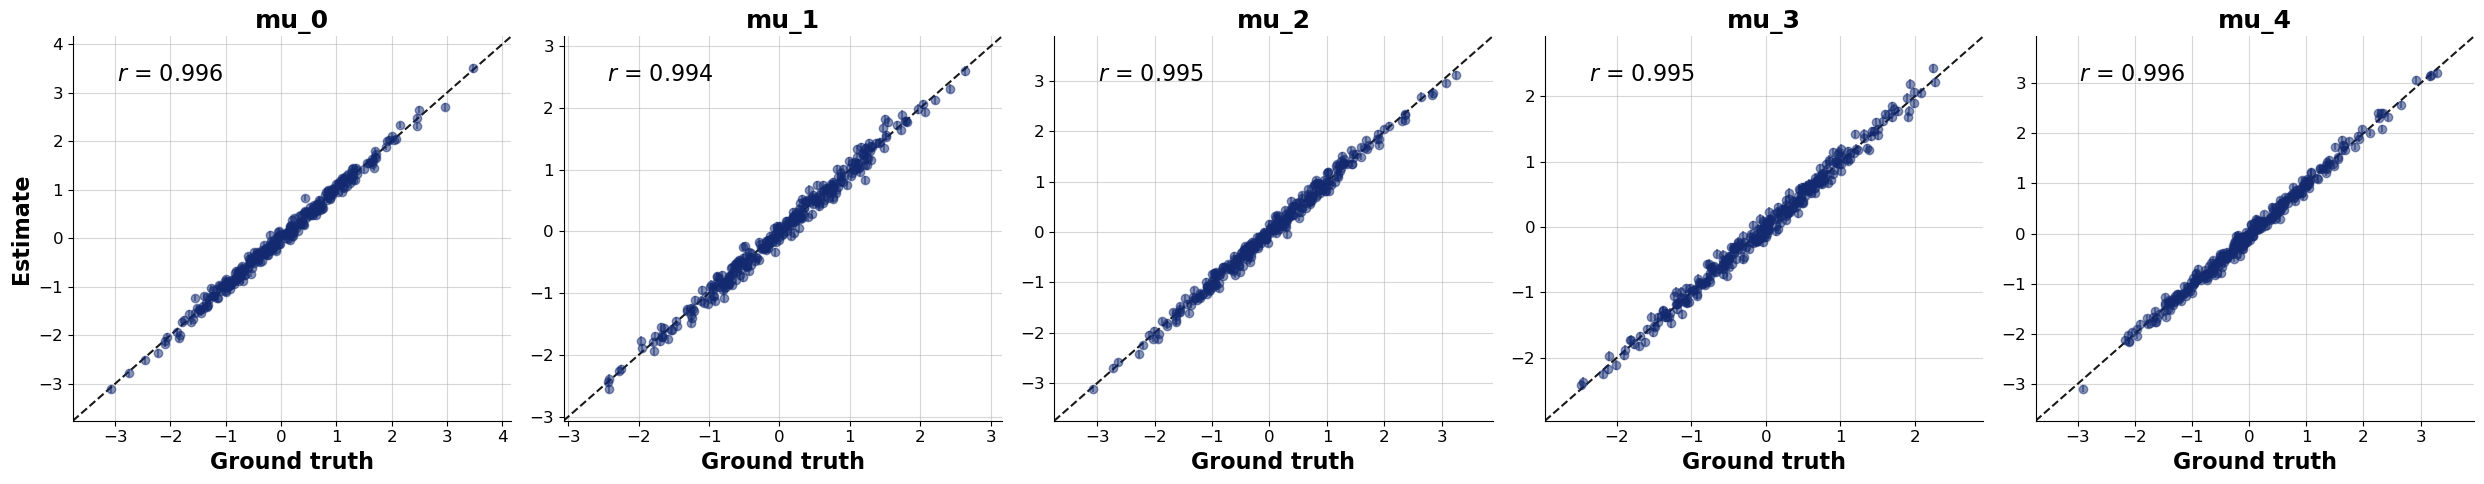

In [161]:
# Generate test datasets and get posterior samples and perform diagnostics
test_sims, posterior_samples = bayesflownpe.test_datasets(number_datasets=300, num_samples=1000)
f1 = bf.diagnostics.plots.calibration_histogram(posterior_samples, test_sims)
f2 = bf.diagnostics.plots.calibration_ecdf(posterior_samples, test_sims,difference=True)
f3 = bf.diagnostics.plots.recovery(posterior_samples, test_sims)

In [6]:
# Save the trained approximator
filepath = Path("/Users/mandyking/benchmark/benchmark/examples/gaussian/networks") / "npe_normal_prior_0.keras"
filepath.parent.mkdir(exist_ok=True)
bayesflownpe.workflow.approximator.save(filepath=filepath)

In [160]:
# Load the trained approximator
filepath = Path("/Users/mandyking/benchmark/benchmark/examples/gaussian/networks") / "npe_normal_prior_0.keras"
approximator=keras.saving.load_model(filepath)
simulator_bayes=Simulator(mu_prior_mean=mu_prior_mean, mu_prior_std=mu_prior_std, 
                                              num_dims=num_dims, num_obs=num_obs,likelihood_std=likelihood_std,rng=RNG)
simulator=simulator_bayes.get_bayes_simulator()
bayesflownpe=BayesFLowNPE(simulator=simulator)
bayesflownpe.workflow.approximator=approximator

In [7]:
# generate datasets 1.mu=0,normal  2. mu=10, noraml 3. mu=0,student_t,df=10
df_normal_0=GetDatasets(obs_mu_prior_mean=0, obs_mu_prior_std=1,
               num_dims=num_dims, num_obs=num_obs, likelihood_std=likelihood_std, 
               num_datasets=50,rng=RNG)
df_normal_10=GetDatasets(obs_mu_prior_mean=10, obs_mu_prior_std=1,
               num_dims=num_dims, num_obs=num_obs, likelihood_std=likelihood_std, 
               num_datasets=50,rng=RNG)
df_student=GetDatasets(obs_mu_prior_mean=0, obs_mu_prior_std=1,
               num_dims=num_dims, num_obs=num_obs, likelihood_std=likelihood_std, 
               use_student_t=True, df=10,
               num_datasets=50,rng=RNG)
datasets_normal_0=df_normal_0.get_datasets_normal()
datasets_normal_10=df_normal_10.get_datasets_normal()
datasets_student=df_student.get_datasets_student_t()


In [ ]:
# read datasets
def load_pickle(path: str):
    with open(path, "rb") as f:
        return pickle.load(f)

datasets_normal_0  = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/01datasets_normal_0.pkl")
datasets_normal_10 = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/01datasets_normal_10.pkl")
datasets_student   = load_pickle("/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/01datasets_student_df10.pkl")



In [8]:
calculation=Calculation(workflow=bayesflownpe,mu_prior_mean=mu_prior_mean, mu_prior_std=mu_prior_std,
                        num_dims=num_dims,num_obs=num_obs,
                 likelihood_std=likelihood_std,num_samples=1000)
datasets_normal_0=calculation.normal_analytical(obs_data=datasets_normal_0)
datasets_normal_0=calculation.npe_estimation(obs_data=datasets_normal_0)

datasets_normal_10=calculation.normal_analytical(obs_data=datasets_normal_10)
datasets_normal_10=calculation.npe_estimation(obs_data=datasets_normal_10)

datasets_student=calculation.normal_analytical(obs_data=datasets_student)
datasets_student=calculation.npe_estimation(obs_data=datasets_student)


In [16]:
# save datasetst
def save_pickle(obj, path: str):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(obj, f)

save_pickle(datasets_normal_0,  "/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/01datasets_normal_0.pkl")
save_pickle(datasets_normal_10, "/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/01datasets_normal_10.pkl")
save_pickle(datasets_student,   "/Users/mandyking/benchmark/benchmark/examples/gaussian/results/datasets/01datasets_student_df10.pkl")

In [17]:
# save datasets for Stan and then run "student_t_gold.r later in studentt neuro network"
save=StanDataset.save_for_stan(datasets_normal_0,output_dir="/Users/mandyking/benchmark/benchmark/examples/gaussian/stan/json_n0",df=10)
save=StanDataset.save_for_stan(datasets_normal_10,output_dir="/Users/mandyking/benchmark/benchmark/examples/gaussian/stan/json_n10",df=10)
save=StanDataset.save_for_stan(datasets_student,output_dir="/Users/mandyking/benchmark/benchmark/examples/gaussian/stan/json_df10",df=10)


✓ Saved 50 datasets with unique IDs

✓ Saved 50 datasets with unique IDs

✓ Saved 50 datasets with unique IDs


In [77]:
# calculate mmd and abs_error_lm for each type of datasets
group_specs = [
    (r"$M_1$", datasets_normal_0),   
    (r"$M_2$", datasets_normal_10),
    (r"$M_3$", datasets_student),   
]
metrics = pd.concat(
    [Analysis.evaluate_mmd_err(ds_list, name) for name, ds_list in group_specs],
    ignore_index=True
)


In [78]:
summary = (metrics
           .groupby("dataset_group")[["mmd", "abs_logml_error"]]
           .agg(["mean", "median", "std", "min", "max"])
           .reset_index())
print(summary)


  dataset_group       mmd                                          \
                     mean    median       std       min       max   
0         $M_1$  0.020315  0.016691  0.008580  0.010753  0.051175   
1         $M_2$  2.467334  2.460617  0.064818  2.298145  2.633679   
2         $M_3$  0.020912  0.018911  0.008174  0.011152  0.055398   

  abs_logml_error                                                       
             mean        median         std          min           max  
0        0.017030      0.012467     0.01683     0.000191      0.101700  
1    11441.004031  11044.045810  1817.74617  7738.938222  16634.534206  
2        0.016515      0.013392     0.01483     0.000426      0.066959  


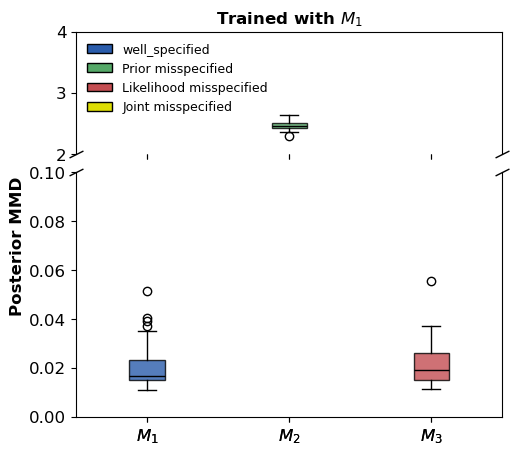

In [ ]:
# boxplot for MMD
groups = [r"$M_1$",r"$M_2$",r"$M_3$"]
data = [metrics.loc[metrics["dataset_group"]==g,"mmd"]
        .dropna().astype(float).values for g in groups]

fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(5.5,5),
    gridspec_kw={"height_ratios":[1,2]}
)

colors = ["#2A5CAB", "#55A868", "#C44E52","#DDDD04"]

labels = ["well_specified",
          "Prior misspecified",
          "Likelihood misspecified",
          "Joint misspecified"]

legend_handles = [
    Patch(facecolor=color, edgecolor='black', label=label)
    for color, label in zip(colors, labels)
]

ax1.legend(handles=legend_handles,
           loc="upper left",
           frameon=False,
           fontsize=9)

bp1 = ax1.boxplot(data, tick_labels=groups,
                   showfliers=True,
                  patch_artist=True,
                  widths=0.25,
                  medianprops=dict(color='black', linewidth=1)
                  )

bp2 = ax2.boxplot(data, tick_labels=groups,
                   showfliers=True,
                  patch_artist=True,
                  widths=0.25,
                  medianprops=dict(color='black', linewidth=1))

for bp in [bp1, bp2]:
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

# broken axis
ax1.set_ylim(2,4)
ax2.set_ylim(0.0, 0.1)

ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax1.tick_params(labeltop=False, labelsize=12)
ax2.tick_params(labelsize=12)
ax2.xaxis.tick_bottom()

d = 0.5
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=10,
              linestyle="none", color="k",
              mec="k", mew=1, clip_on=False)

ax1.plot([0,1], [0,0], transform=ax1.transAxes, **kwargs)
ax2.plot([0,1], [1,1], transform=ax2.transAxes, **kwargs)

ax2.set_ylabel("Posterior MMD",
               fontsize=12,
               )

ax2.yaxis.set_label_coords(-0.12, 0.7)

ax1.set_title(
    r"Trained with $M_1$",
    fontsize=12,
    
)

plt.subplots_adjust(hspace=0.1)
plt.show()

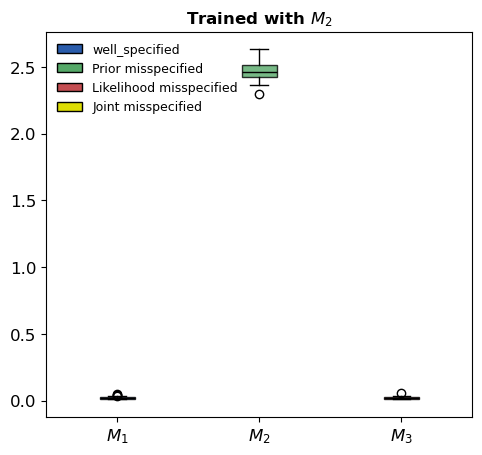

In [159]:
# boxplot for MMD
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold"
})

groups = [name for name, _ in group_specs]

data = []
for g in groups:
    s = metrics.loc[metrics["dataset_group"] == g, "mmd"]
    arr = pd.to_numeric(s, errors="coerce").dropna().astype(float).tolist()
    data.append(arr)

colors = ["#55A868","#2A5CAB", "#DDDD04",]

fig, ax = plt.subplots(figsize=(5.5, 5))

colors = ["#2A5CAB", "#55A868", "#C44E52","#DDDD04"]

labels = ["well_specified",
          "Prior misspecified",
          "Likelihood misspecified",
          "Joint misspecified"]

legend_handles = [
    Patch(facecolor=color, edgecolor='black', label=label)
    for color, label in zip(colors, labels)
]
ax.legend(handles=legend_handles,
           loc="upper left",
           frameon=False,
           fontsize=9)
bp = ax.boxplot(
    data,
    tick_labels=groups,
    patch_artist=True,
    widths=0.25,
    medianprops=dict(color='black', linewidth=1)
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)


ax.set_title(
    r"Trained with $M_2$",
    fontsize=12
)

plt.subplots_adjust(hspace=0.1)
plt.show()

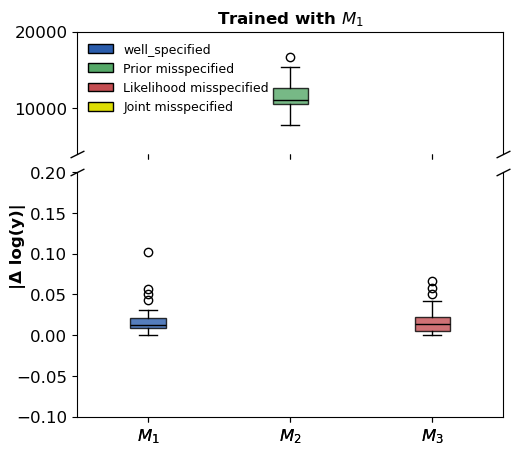

In [ ]:
# boxplot for absolute logml error
groups = [r"$M_1$",r"$M_2$",r"$M_3$"]
data = [metrics.loc[metrics["dataset_group"]==g,"abs_logml_error"]
        .dropna().astype(float).values for g in groups]

fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(5.5,5),
    gridspec_kw={"height_ratios":[1,2]}
)

colors = ["#2A5CAB", "#55A868", "#C44E52","#DDDD04"]

labels = ["well_specified",
          "Prior misspecified",
          "Likelihood misspecified",
          "Joint misspecified"]

legend_handles = [
    Patch(facecolor=color, edgecolor='black', label=label)
    for color, label in zip(colors, labels)
]

ax1.legend(handles=legend_handles,
           loc="upper left",
           frameon=False,
           fontsize=9)

bp1 = ax1.boxplot(data, tick_labels=groups,
                   showfliers=True,
                  patch_artist=True,
                  widths=0.25,
                  medianprops=dict(color='black', linewidth=1)
                  )

bp2 = ax2.boxplot(data, tick_labels=groups,
                   showfliers=True,
                  patch_artist=True,
                  widths=0.25,
                  medianprops=dict(color='black', linewidth=1))

for bp in [bp1, bp2]:
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)


ax1.set_ylim(4000,20000)     
ax2.set_ylim(-0.1,0.2)  



ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax1.tick_params(labeltop=False, labelsize=12)
ax2.tick_params(labelsize=12)
ax2.xaxis.tick_bottom()

d = 0.5
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=10,
              linestyle="none", color="k",
              mec="k", mew=1, clip_on=False)

ax1.plot([0,1], [0,0], transform=ax1.transAxes, **kwargs)
ax2.plot([0,1], [1,1], transform=ax2.transAxes, **kwargs)

ax2.set_ylabel("|Δ log(y)|",
               fontsize=12,
               )

ax2.yaxis.set_label_coords(-0.12, 0.7)

ax1.set_title(
    r"Trained with $M_1$",
    fontsize=12,
    
)

plt.subplots_adjust(hspace=0.1)
plt.show()



In [39]:
evidence_dic = {}

for d in datasets_normal_0:
    dataset_id = d["id"]
    
    evidence_dic[dataset_id] = {
        "id": dataset_id,
        "gold_lm_M1": d["gold_log_marginal"],
        "npe_lm_M1": d["npe_log_marginal"]
    }

In [40]:
print(evidence_dic)

{0: {'id': 0, 'gold_lm_M1': -731.1379389196842, 'npe_lm_M1': -731.1500481930746}, 1: {'id': 1, 'gold_lm_M1': -721.8244805959305, 'npe_lm_M1': -721.8143605003435}, 2: {'id': 2, 'gold_lm_M1': -718.3989998441974, 'npe_lm_M1': -718.4426491017662}, 3: {'id': 3, 'gold_lm_M1': -721.6601470291371, 'npe_lm_M1': -721.6570155730636}, 4: {'id': 4, 'gold_lm_M1': -695.497370802632, 'npe_lm_M1': -695.4971797884843}, 5: {'id': 5, 'gold_lm_M1': -719.5397280765167, 'npe_lm_M1': -719.5316555344504}, 6: {'id': 6, 'gold_lm_M1': -741.7003141352246, 'npe_lm_M1': -741.6820340927038}, 7: {'id': 7, 'gold_lm_M1': -732.4572536543087, 'npe_lm_M1': -732.4518881919987}, 8: {'id': 8, 'gold_lm_M1': -718.3127310653147, 'npe_lm_M1': -718.3354125504972}, 9: {'id': 9, 'gold_lm_M1': -725.133952804825, 'npe_lm_M1': -725.1232810701281}, 10: {'id': 10, 'gold_lm_M1': -731.2878271849643, 'npe_lm_M1': -731.2766224040835}, 11: {'id': 11, 'gold_lm_M1': -702.7422933175178, 'npe_lm_M1': -702.7632208181518}, 12: {'id': 12, 'gold_lm_M

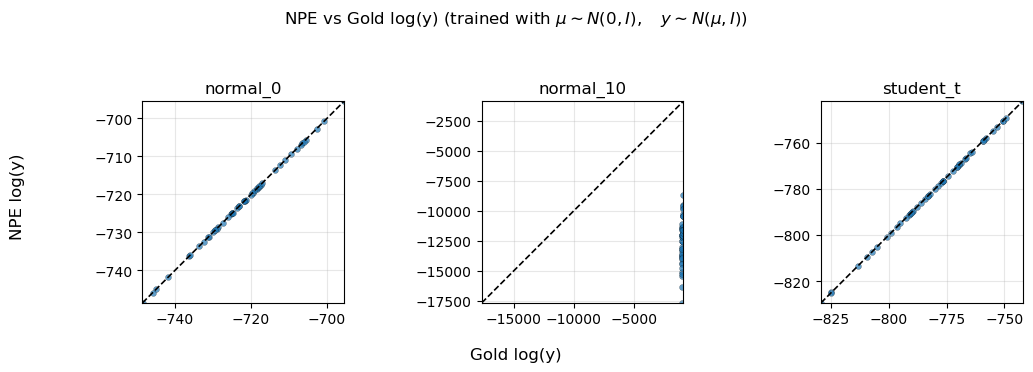

In [55]:
groups = ["normal_0", "normal_10", "student_t"]
xcol = "gold_logml"
ycol = "npe_logml"

fig, ax = plt.subplots(1, len(groups), figsize=(11, 3.6), sharey=False)

if len(groups) == 1:
    ax = [ax]

for i, g in enumerate(groups):
    sub = metrics.loc[metrics["dataset_group"] == g, [xcol, ycol]].dropna()
    x = sub[xcol].astype(float).to_numpy()
    y = sub[ycol].astype(float).to_numpy()
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    ax[i].scatter(x, y, s=18, alpha=0.7, marker="o", edgecolors="k", linewidths=0.2)
    ax[i].plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1.2)
    ax[i].set_xlim(lo, hi)
    ax[i].set_ylim(lo, hi)
    ax[i].set_aspect("equal", adjustable="box")
    ax[i].grid(True, alpha=0.3)
    ax[i].set_title(g)
fig.supxlabel("Gold log(y)", y=0.04)
fig.supylabel("NPE log(y)", x=0.04)
fig.suptitle(r"NPE vs Gold log(y) (trained with $\mu \sim N(0, I), \quad y \sim N(\mu, I)$)", y=1.02)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.92])
plt.show()